# Нелинейная модель для предсказания справедливой стоимости поддержанных автомобилей с учетом бизнес-рисков

## Введение

**Бизнес-контекст и цель проекта**  
Компания заинтересована в снижении рисков, связанных с человеческим фактором, а также в обеспечении быстродействия и масштабируемости процессов оценки автомобилей. Внедрение автоматической системы оценки позволит стартапу увеличить долю рынка и повысить прибыльность бизнеса.  
**Цель работы** — создание модели машинного обучения, способной быстро вычислять справедливую стоимость автомобиля для принятия решения о его покупке.

**Используемые данные**  
Источник: внутренние данные компании о совершённых сделках (цена автомобиля, пробег, количество владельцев и другие характеристики).

**Формализация задачи машинного обучения**  
- Объект наблюдения: автомобиль.  
- Целевая переменная: цена автомобиля (числовое значение).  
- Тип задачиочной выборкахровочной выборках

<a id='1'></a>
## Загрузка необходимых библиотек

In [8]:
# !pip install phik -q
# !pip install optuna -q
# !pip install shap -q
# !pip install lightgbm -q
# !pip install catboost -q

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer, confusion_matrix
import optuna
from sklearn.tree import plot_tree
import shap

In [11]:
# !pip freeze > requirements.txt

In [12]:
RANDOM_SEED = 42

<a id='2'></a>
# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

In [14]:
df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_train_data.csv')
df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_test_data.csv')

In [15]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 1.1 MB


In [16]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 288.2 KB


Было выгружено 2 таблицы с данными о продажах машин, по большей части данные представлены характеристиками машин:
  - Таблица df_train: 13 столбцов и 8000 строк
  - Таблица df_test: 13 столбцов и 2000 строк

Пустых значений в данных нет

In [18]:
full_df = pd.concat([df_train, df_test], axis=0)

In [19]:
full_df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


<a id='3'></a>
## Исследовательский анализ данных

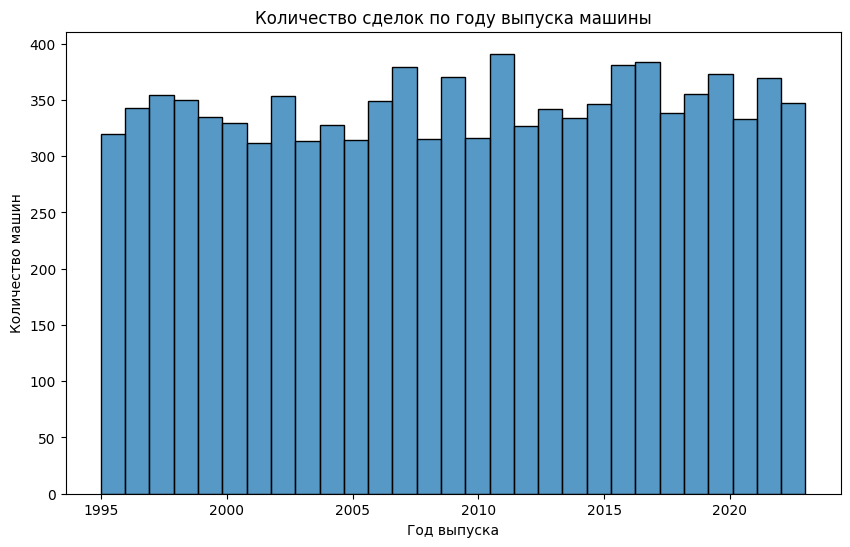

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(data=full_df, x='make_year', bins=full_df['make_year'].max() - full_df['make_year'].min() + 1)
plt.title("Количество сделок по году выпуска машины")
plt.xlabel("Год выпуска")
plt.ylabel("Количество машин")
plt.show()

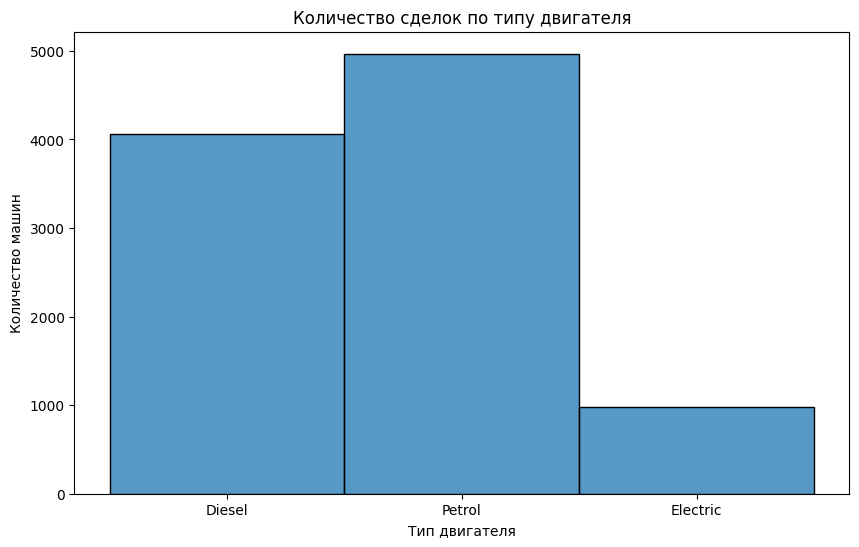

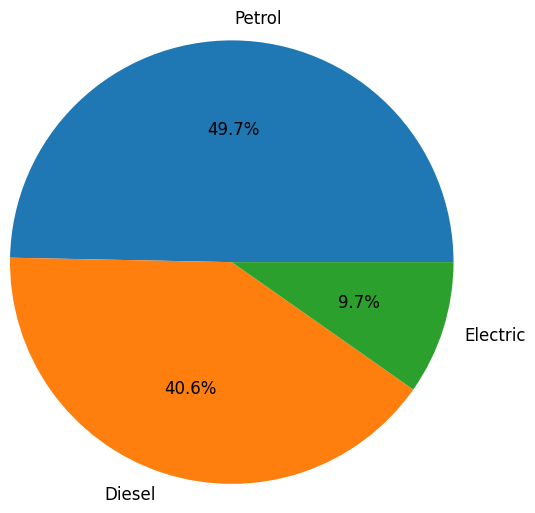

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=full_df, x='fuel_type')
plt.title("Количество сделок по типу двигателя")
plt.xlabel("Тип двигателя")
plt.ylabel("Количество машин")
plt.show()


labels = full_df['fuel_type'].value_counts().index
sizes = full_df['fuel_type'].value_counts().values
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.show()

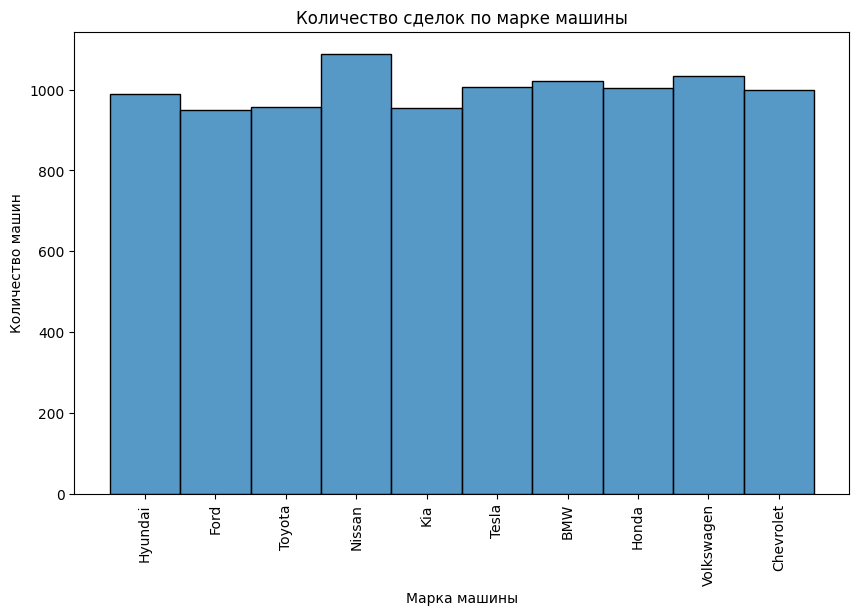

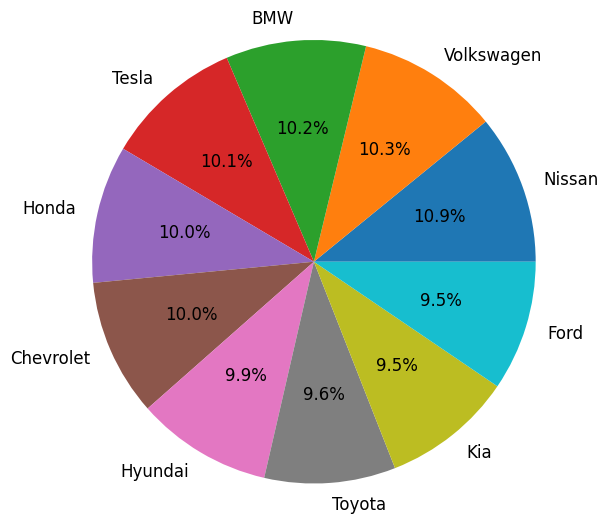

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(data=full_df, x='brand')
plt.title("Количество сделок по марке машины")
plt.xlabel("Марка машины")
plt.ylabel("Количество машин")
plt.xticks(rotation=90)
plt.show()


labels = full_df['brand'].value_counts().index
sizes = full_df['brand'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.show()

Доля сделок с машинами в зависимости от типа коробки передач


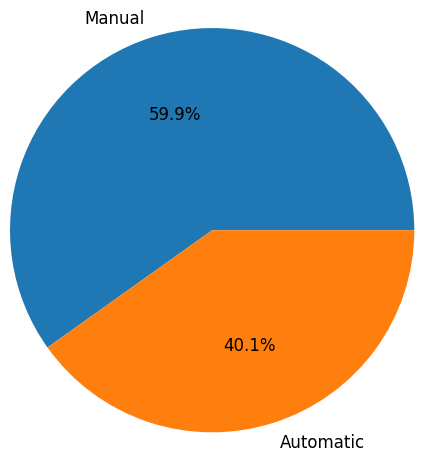

In [25]:
labels = full_df['transmission'].value_counts().index
sizes = full_df['transmission'].value_counts().values


print('Доля сделок с машинами в зависимости от типа коробки передач')
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.tight_layout()
plt.show()

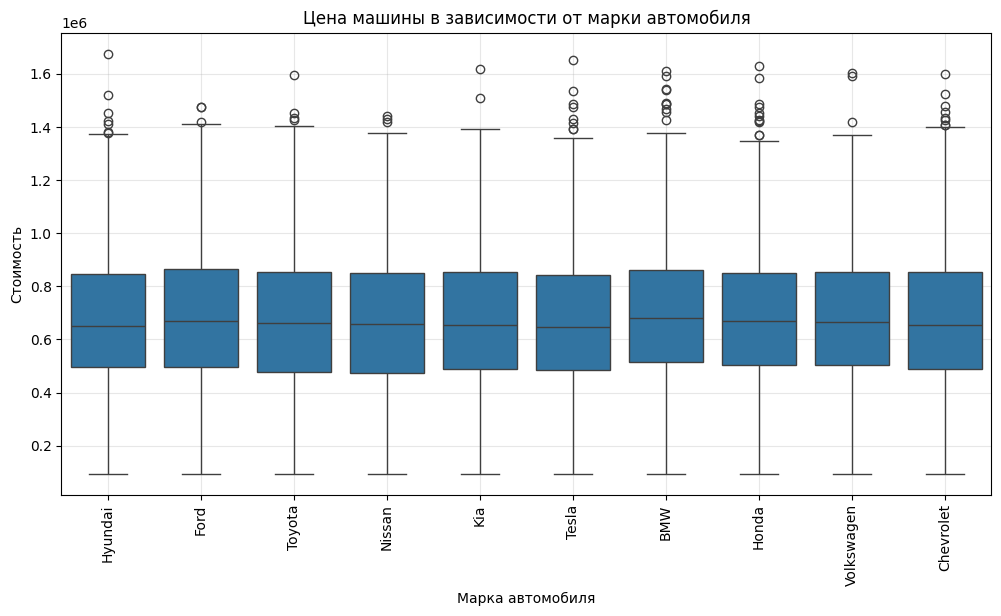

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=full_df, x='brand', y='price_rub')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.title('Цена машины в зависимости от марки автомобиля')
plt.xlabel('Марка автомобиля')
plt.ylabel('Стоимость')
plt.show()

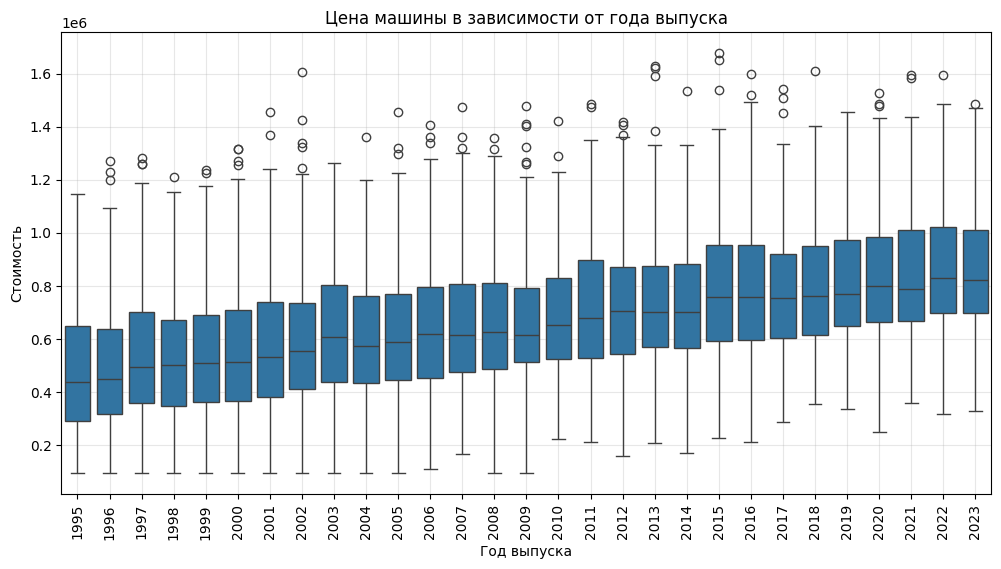

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=full_df, x='make_year', y='price_rub')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.title('Цена машины в зависимости от года выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Стоимость')
plt.show()

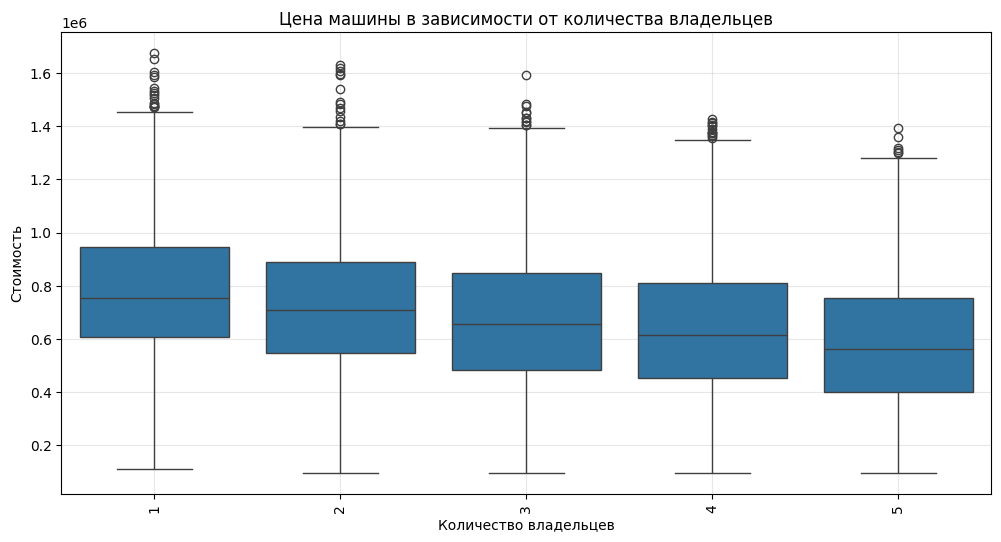

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=full_df, x='owner_count', y='price_rub')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.title('Цена машины в зависимости от количества владельцев')
plt.xlabel('Количество владельцев')
plt.ylabel('Стоимость')
plt.show()

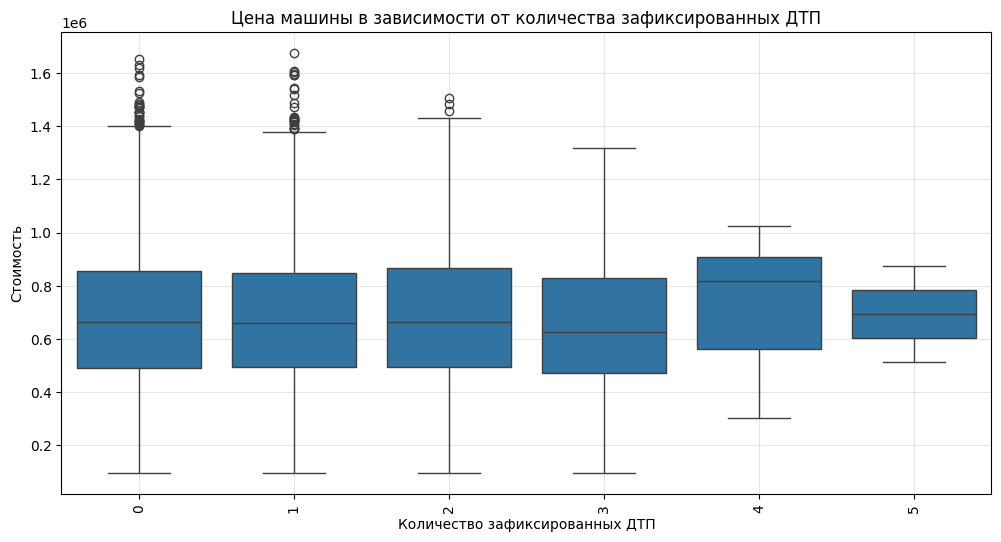

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=full_df, x='accidents_reported', y='price_rub')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.title('Цена машины в зависимости от количества зафиксированных ДТП')
plt.xlabel('Количество зафиксированных ДТП')
plt.ylabel('Стоимость')
plt.show()

Доля сделок с действительной стрховкой


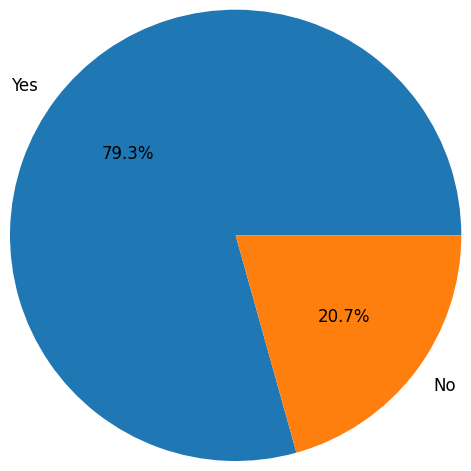

In [30]:
labels = full_df['insurance_valid'].value_counts().index
sizes = full_df['insurance_valid'].value_counts().values


print('Доля сделок с действительной стрховкой')
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.tight_layout()
plt.show()

Наличие сервисной книжки


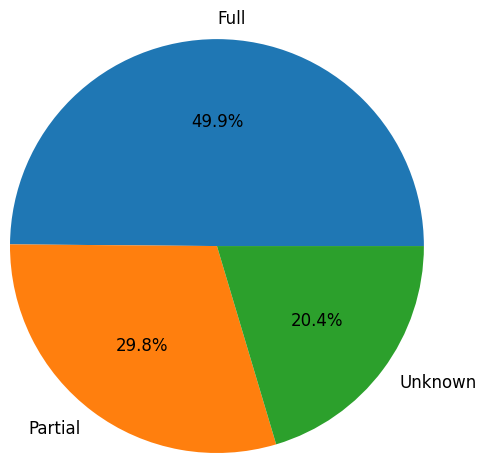

In [31]:
labels = full_df['service_history'].value_counts().index
sizes = full_df['service_history'].value_counts().values


print('Наличие сервисной книжки')
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.tight_layout()
plt.show()

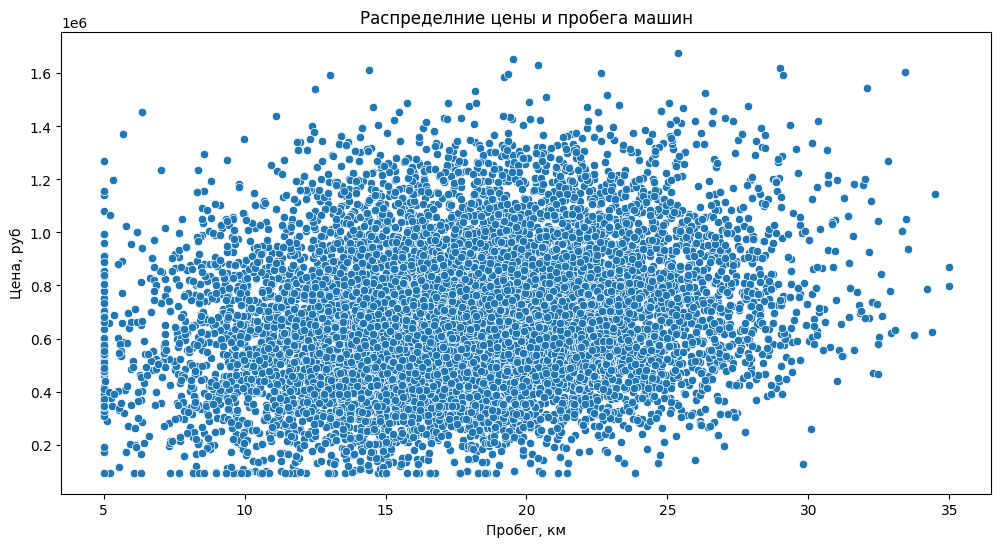

In [32]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=full_df, x="mileage_kmpl", y="price_rub")
plt.title('Распределние цены и пробега машин')
plt.xlabel('Пробег, км')
plt.ylabel('Цена, руб')
plt.show()

Доля цветов машин


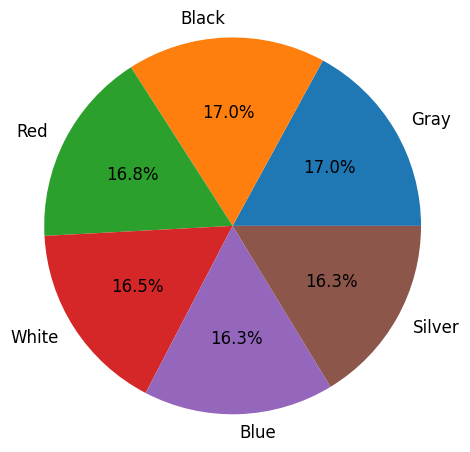

In [33]:
labels = full_df['color'].value_counts().index
sizes = full_df['color'].value_counts().values

print('Доля цветов машин')
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.tight_layout()
plt.show()

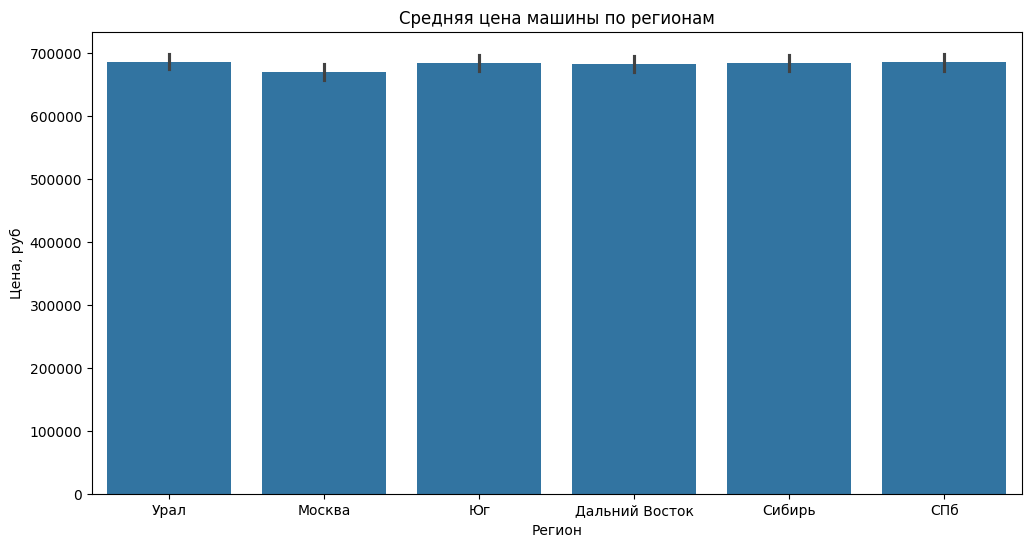

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=full_df, x="region", y="price_rub")
plt.title('Средняя цена машины по регионам')
plt.xlabel('Регион')
plt.ylabel('Цена, руб')
plt.show()

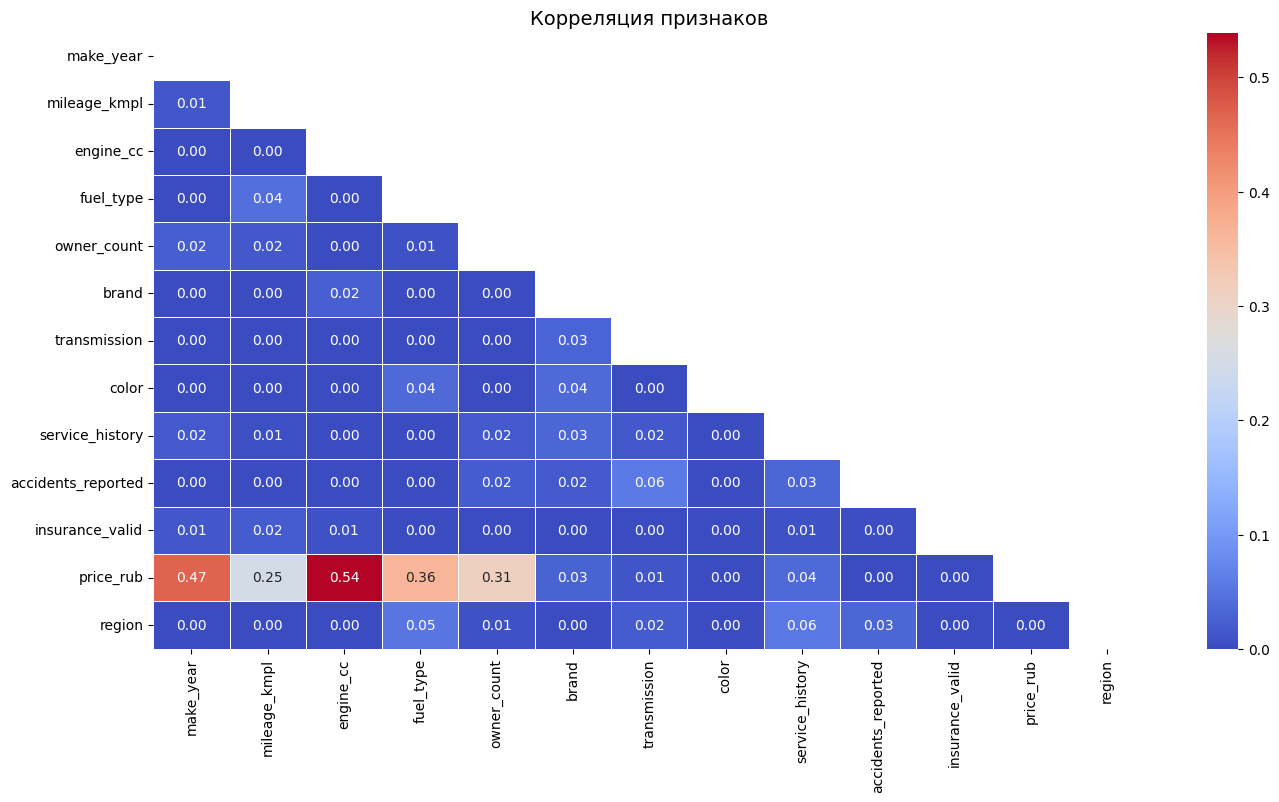

In [35]:
# Корреляция
interval_cols = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported', 'price_rub']

corr_data = full_df.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(16, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков', fontsize=14)
plt.show()

In [36]:
print(f'Количество дубликатов: {full_df.duplicated().sum()}')

Количество дубликатов: 0


Выводы:
  - В данных представлены машины с годом выпуска от 1995 до 2023 г
  - Наибольшее количество сделок - 49.7% совершается с автомобилями бензинового типа топлива, 40.6% сделок с дизельным типом, и наименьшее, 9.7% - с электрическим типом
  - Количество сделок с автомобилями распределено примерно равномерно по всем маркам машин (9.5%-10.9% на марку), за исключением марки Nissan, где количество сделок немного больше прочих
  - 59.9% сделок представляют машины с ручной коробкой передач
  - Медианная стоимость автомобиля для всех марок примерно равна и составляет ~650 тыс руб.
  - На графике видно прямую зависимость между ценой автомобиля и годом его выпуска, т.е. чем новее автомобиль, тем он дороже
  - Между количеством владельцев и ценой автомобиля наблюдается обратная зависимость
  - Разброс цены автомобиля снижается с увеличением количества зарегестрированных ДТП
  - 79.3% сделок совершены с действительной страховкой, 20.7% сделок с истекшей
  - 49.9% сделок соверешены с полной сервисной книжкой, 29.8% с частичной, информация о 20.4% неизвестна
  - Цвета автомобилей распределны примерно одинаково: самые редкий - серебристый (16.3% машин), самый популярный - черный и серый (по 17% машин)
  - В Москве средняя цена на автомобили слегка меньше чем в остальных регионах
  - В результате анализа корреляции наболее выражанную связь с целевым признаком показывают признаки: год выпуска машины (0.47), пробег (0.25), объем двигателя (0.54), тип топлива (0.36) и количество владельцев (0.31)
  - Полных дубликатов в данных нет

<a id='4'></a>
# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

In [40]:
df_train.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [41]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 1.1 MB


In [42]:
# Категориальные столбцы
cat_columns = ["fuel_type", "brand", "transmission", 
               "color", "service_history", "insurance_valid", "region"]

for col in cat_columns:
    df_train[col] = df_train[col].astype('category')
    df_test[col] = df_test[col].astype('category')

In [43]:
X = df_train.drop(columns='price_rub')
y = df_train['price_rub']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

X_test = df_test.drop(columns='price_rub')
y_test = df_test['price_rub']

print(f"Количество записей в тренировочной выборке {len(X_train)} ({len(X_train) / (len(X_train)+len(X_val)+len(X_test)) * 100}%)")
print(f"Количество записей в валидационной выборке {len(X_val)} ({len(X_val) / (len(X_train)+len(X_val)+len(X_test)) * 100}%)")
print(f"Количество записей в тестовой выборке {len(X_test)} ({len(X_test) / (len(X_train)+len(X_val)+len(X_test)) * 100}%)")


df_val = X_val.copy()
df_val['true'] = y_val

Количество записей в тренировочной выборке 6000 (60.0%)
Количество записей в валидационной выборке 2000 (20.0%)
Количество записей в тестовой выборке 2000 (20.0%)


In [46]:
# Определяем бизнес метрики
def get_overpricing_rate(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    overpricing_rate = (error_ratio > 0.20).mean()
    return round(overpricing_rate, 3)

def get_underpricing_loss(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    under_mask = error_ratio < -0.20
    underpricing_loss = (y_true[under_mask] - y_pred[under_mask]).sum()
    return round(underpricing_loss, 1)

def get_underpricing_rate(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    underpricing_rate = (error_ratio < -0.20).mean()
    return round(underpricing_rate, 3)

<a id='5'></a>
# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

In [49]:
xgb = XGBRegressor(random_state=RANDOM_SEED, enable_categorical=True, eval_metric="mae")
xgb.fit(X_train, y_train, verbose=True, eval_set=[(X_train, y_train), (X_val, y_val)])

lgbm = LGBMRegressor(random_state=RANDOM_SEED)
lgbm.fit(X_train, y_train, categorical_feature=cat_columns,
         eval_set=[(X_train, y_train), (X_val, y_val)],
         eval_metric="mae")

catb = CatBoostRegressor(random_state=RANDOM_SEED)
catb.fit(X_train, y_train, cat_features=cat_columns,
         eval_set=(X_val, y_val),
         verbose=200)

[0]	validation_0-mae:164513.15857	validation_1-mae:165376.62959
[1]	validation_0-mae:131633.55758	validation_1-mae:134311.37905
[2]	validation_0-mae:110555.10576	validation_1-mae:115162.04928
[3]	validation_0-mae:96052.50498	validation_1-mae:103140.35973
[4]	validation_0-mae:86783.85322	validation_1-mae:96112.25883
[5]	validation_0-mae:80595.33004	validation_1-mae:91662.86355
[6]	validation_0-mae:76388.82971	validation_1-mae:88627.38401
[7]	validation_0-mae:73512.05661	validation_1-mae:86721.54872
[8]	validation_0-mae:71359.49483	validation_1-mae:85656.83537
[9]	validation_0-mae:69701.79770	validation_1-mae:84984.80411
[10]	validation_0-mae:68335.89590	validation_1-mae:84401.28873
[11]	validation_0-mae:67157.23496	validation_1-mae:84252.35241
[12]	validation_0-mae:66222.18386	validation_1-mae:84143.63538
[13]	validation_0-mae:65424.09232	validation_1-mae:84129.67978
[14]	validation_0-mae:64612.38364	validation_1-mae:84086.69808
[15]	validation_0-mae:64095.84074	validation_1-mae:84031.7

CatBoostRegressor(loss_function='RMSE', random_state=42)

In [53]:
y_pred_xgb = xgb.predict(X_val)
y_pred_lgbm = lgbm.predict(X_val)
y_pred_catb = catb.predict(X_val)

In [54]:
def get_metrics(y_true, y_pred, model_name):

    mae = round(mean_absolute_error(y_true, y_pred), 2)
    rmse = round(mean_squared_error(y_true, y_pred)**(1/2), 2)
    r2 = round(r2_score(y_true, y_pred), 3)
    
    overpricing_rate = get_overpricing_rate(y_true, y_pred)
    underpricing_loss = get_underpricing_loss(y_true, y_pred)
    underpricing_rate = get_underpricing_rate(y_true, y_pred)
    
    res_df = pd.DataFrame({
        'model' : [model_name],
        'mae' : [mae],
        'rmse' : [rmse],
        'r2' : [r2],
        'overpricing_rate' : [overpricing_rate],
        'underpricing_loss' : [underpricing_loss],
        'underpricing_rate' : [underpricing_rate]
    })

    return res_df

In [55]:
res_table = get_metrics(y_val, y_pred_xgb, 'xgb_base')
res_table = pd.concat([res_table, get_metrics(y_val, y_pred_lgbm, 'lgbm_base')])
res_table = pd.concat([res_table, get_metrics(y_val, y_pred_catb, 'catb_base')])

In [56]:
res_table

,model,mae,rmse,r2,overpricing_rate,underpricing_loss,underpricing_rate
0,xgb_base,88219.86,110178.62,0.828,0.149,32942357.5,0.096
0,lgbm_base,82289.19,102267.59,0.852,0.139,25030886.5,0.076
0,catb_base,79530.94,99195.47,0.860,0.137,22704224.1,0.069


Наилучшей моделью с точки зрения базовых метрик (RMSE, MAE, R2) является Catboost

С точки зрения бизнес метрик Catboost и LightGBM очень похожи, однако значение underpricing_rate для lgbm_base на 0.015 ниже

<a id='6'></a>
# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


In [60]:
def objective_xgb(trial):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
        "enable_categorical": True,
        "verbosity": 0,
    }
    mae_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        preds = model.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, preds))
    
    return np.mean(mae_scores)

In [61]:
def objective_cat(trial):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_seed": RANDOM_SEED,
        "logging_level": "Silent",
        "cat_features": cat_columns,
    }
    mae_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )
        preds = model.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, preds))
    
    return np.mean(mae_scores)

In [72]:
def objective_lgb(trial):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        "random_state": RANDOM_SEED,
        "verbose": -1,
        "n_jobs": -1,
    }
    mae_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="mae",
            categorical_feature=cat_columns,
            callbacks=[lgb.early_stopping(stopping_rounds=50)]
        )
        preds = model.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, preds))
    
    return np.mean(mae_scores)

In [64]:
start_time = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective_xgb, n_trials=10, show_progress_bar=False)
print(f"Время подбора гиперпараметров для xgboost: {time.time() - start_time}")

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение MAE на кросс-валидации:", best_value)

best_xgb = XGBRegressor(enable_categorical=True, **best_params)

[I 2026-04-30 10:35:14,676] A new study created in memory with name: no-name-61a53e28-3b07-4a4e-a714-db427c0df4ac
[I 2026-04-30 10:36:17,631] Trial 0 finished with value: 85883.45625 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.5986584882104518}. Best is trial 0 with value: 85883.45625.
[I 2026-04-30 10:36:21,931] Trial 1 finished with value: 77268.6296875 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 4, 'n_estimators': 587, 'gamma': 0.8661761471131737}. Best is trial 1 with value: 77268.6296875.
[I 2026-04-30 10:36:33,018] Trial 2 finished with value: 83816.04375 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 8, 'n_estimators': 530, 'gamma': 0.9699098524628958}. Best is trial 1 with value: 77268.6296875.
[I 2026-04-30 10:36:38,555] Trial 3 finished with value: 80455.15 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180

Время подбора гиперпараметров для xgboost: 203.18258571624756
Лучшие гиперпараметры: {'learning_rate': 0.014322493718230255, 'max_depth': 4, 'n_estimators': 587, 'gamma': 0.8661761471131737}
Лучшее среднее значение MAE на кросс-валидации: 77268.6296875


In [66]:
start_time = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective_cat, n_trials=10, show_progress_bar=False)
print(f"Время подбора гиперпараметров для Catboost: {time.time() - start_time}")

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение MAE на кросс-валидации:", best_value)

best_catb = CatBoostRegressor(**best_params)

[I 2026-04-30 10:38:37,939] A new study created in memory with name: no-name-0b8eb00a-4f5e-448e-bfb1-863aad40eb92
[I 2026-04-30 10:40:35,792] Trial 0 finished with value: 76548.3373895887 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 10, 'iterations': 1598, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 76548.3373895887.
[I 2026-04-30 10:41:15,546] Trial 1 finished with value: 76062.66109623753 and parameters: {'learning_rate': 0.014322493718230255, 'depth': 4, 'iterations': 587, 'l2_leaf_reg': 8.795585311974417}. Best is trial 1 with value: 76062.66109623753.
[I 2026-04-30 10:42:23,101] Trial 2 finished with value: 76409.13268951308 and parameters: {'learning_rate': 0.039913058785616795, 'depth': 8, 'iterations': 530, 'l2_leaf_reg': 9.72918866945795}. Best is trial 1 with value: 76062.66109623753.
[I 2026-04-30 10:42:47,896] Trial 3 finished with value: 75761.02434417143 and parameters: {'learning_rate': 0.06798962421591129, 'depth': 4, 'iterations':

Время подбора гиперпараметров для Catboost: 769.2741816043854
Лучшие гиперпараметры: {'learning_rate': 0.03912141628549695, 'depth': 3, 'iterations': 1411, 'l2_leaf_reg': 2.5347171131856236}
Лучшее среднее значение MAE на кросс-валидации: 75473.88454825744


In [74]:
start_time = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective_lgb, n_trials=10, show_progress_bar=False)
print(f"Время подбора гиперпараметров для LightGBM: {time.time() - start_time}")

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение MAE на кросс-валидации:", best_value)

best_lgb = LGBMRegressor(**best_params)

[I 2026-04-30 10:54:03,182] A new study created in memory with name: no-name-2af07913-6433-4efb-a15f-6b2b1467dc93


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[145]	valid_0's l1: 79065.2	valid_0's l2: 9.96975e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[221]	valid_0's l1: 76076.8	valid_0's l2: 9.4084e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[174]	valid_0's l1: 83947.5	valid_0's l2: 1.12355e+10
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[165]	valid_0's l1: 78768.4	valid_0's l2: 9.90715e+09
Training until validation scores don't improve for 50 rounds


[I 2026-04-30 10:54:08,238] Trial 0 finished with value: 79683.64123842854 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'num_leaves': 161, 'min_child_samples': 19, 'reg_alpha': 0.15599452877625744, 'reg_lambda': 0.05808362158736334}. Best is trial 0 with value: 79683.64123842854.


Early stopping, best iteration is:
[194]	valid_0's l1: 80560.2	valid_0's l2: 1.01931e+10
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[67]	valid_0's l1: 76665.2	valid_0's l2: 9.44357e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[97]	valid_0's l1: 75252.1	valid_0's l2: 9.0561e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[90]	valid_0's l1: 81158.2	valid_0's l2: 1.04587e+10
Training until validation scores don't improve for 50 rounds


[I 2026-04-30 10:54:09,173] Trial 1 finished with value: 77546.81058976034 and parameters: {'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1562, 'num_leaves': 24, 'min_child_samples': 98, 'reg_alpha': 0.8324426424759953, 'reg_lambda': 0.21233911855488502}. Best is trial 1 with value: 77546.81058976034.


...

Early stopping, best iteration is:
[428]	valid_0's l1: 79708.2	valid_0's l2: 9.9364e+09
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[535]	valid_0's l1: 76246.2	valid_0's l2: 9.25993e+09
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[567]	valid_0's l1: 74492.1	valid_0's l2: 8.80232e+09
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[567]	valid_0's l1: 80449	valid_0's l2: 1.04204e+10
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[567]	valid_0's l1: 76208.4	valid_0's l2: 9.18989e+09
Training until validation scores don't improve for 50 rounds


[I 2026-04-30 10:54:29,831] Trial 8 finished with value: 77289.96410922534 and parameters: {'learning_rate': 0.012260057359187526, 'max_depth': 4, 'n_estimators': 567, 'num_leaves': 97, 'min_child_samples': 42, 'reg_alpha': 0.2713490390604056, 'reg_lambda': 0.8287375108645543}. Best is trial 4 with value: 76688.19372919566.


Did not meet early stopping. Best iteration is:
[565]	valid_0's l1: 79054.1	valid_0's l2: 9.70647e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[254]	valid_0's l1: 75955.3	valid_0's l2: 9.21084e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[284]	valid_0's l1: 74683.4	valid_0's l2: 8.88052e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[284]	valid_0's l1: 80332	valid_0's l2: 1.03017e+10
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[322]	valid_0's l1: 76203.8	valid_0's l2: 9.18729e+09
Training until validation scores don't improve for 50 rounds


[I 2026-04-30 10:54:31,476] Trial 9 finished with value: 77228.29868419477 and parameters: {'learning_rate': 0.02273805573563183, 'max_depth': 5, 'n_estimators': 1314, 'num_leaves': 53, 'min_child_samples': 82, 'reg_alpha': 0.07455065293426438, 'reg_lambda': 0.986886936731648}. Best is trial 4 with value: 76688.19372919566.


Early stopping, best iteration is:
[373]	valid_0's l1: 78967	valid_0's l2: 9.72801e+09
Время подбора гиперпараметров для LightGBM: 28.297667980194092
Лучшие гиперпараметры: {'learning_rate': 0.03912141628549695, 'max_depth': 3, 'n_estimators': 1411, 'num_leaves': 60, 'min_child_samples': 11, 'reg_alpha': 0.9488855377644779, 'reg_lambda': 0.965632033418239}
Лучшее среднее значение MAE на кросс-валидации: 76688.19372919566


In [77]:
best_xgb.fit(X_train, y_train)
best_catb.fit(X_train, y_train, cat_features=cat_columns)
best_lgb.fit(X_train, y_train, categorical_feature=cat_columns)

y_pred_val_b_xgb = best_xgb.predict(X_val)
y_pred_val_b_catb = best_catb.predict(X_val)
y_pred_val_b_lgb = best_lgb.predict(X_val)

res_table = pd.concat([res_table, get_metrics(y_val, y_pred_val_b_xgb, 'xgb_optimized')])
res_table = pd.concat([res_table, get_metrics(y_val, y_pred_val_b_catb, 'catb_optimized')])
res_table = pd.concat([res_table, get_metrics(y_val, y_pred_val_b_lgb, 'lgbm_optimized')])

0:	learn: 258853.2490329	total: 9.75ms	remaining: 13.7s
1:	learn: 253208.0734531	total: 22.1ms	remaining: 15.6s
2:	learn: 247654.6997873	total: 33.7ms	remaining: 15.8s
3:	learn: 242418.6705570	total: 45.7ms	remaining: 16.1s
4:	learn: 237407.1962479	total: 57.2ms	remaining: 16.1s
5:	learn: 232698.0432398	total: 69.3ms	remaining: 16.2s
6:	learn: 228186.9776443	total: 80.7ms	remaining: 16.2s
7:	learn: 223840.1089019	total: 90.1ms	remaining: 15.8s
8:	learn: 219577.2319177	total: 100ms	remaining: 15.6s
9:	learn: 215543.1324363	total: 109ms	remaining: 15.3s
10:	learn: 211791.8353449	total: 119ms	remaining: 15.2s
11:	learn: 208014.7740989	total: 129ms	remaining: 15.1s
12:	learn: 204433.7417962	total: 139ms	remaining: 14.9s
13:	learn: 201097.1595999	total: 148ms	remaining: 14.8s
14:	learn: 197902.2267167	total: 157ms	remaining: 14.6s
15:	learn: 194749.9768947	total: 167ms	remaining: 14.6s
16:	learn: 191874.1086291	total: 178ms	remaining: 14.6s
17:	learn: 188970.9773770	total: 189ms	remaining: 

In [78]:
res_table

,model,mae,rmse,r2,overpricing_rate,underpricing_loss,underpricing_rate
0,xgb_base,88219.86,110178.62,0.828,0.149,32942357.5,0.096
0,lgbm_base,82289.19,102267.59,0.852,0.139,25030886.5,0.076
0,catb_base,79530.94,99195.47,0.860,0.137,22704224.1,0.069
0,xgb_optimized,80653.88,100468.74,0.857,0.138,22524050.0,0.066
0,catb_optimized,79278.45,98853.96,0.861,0.130,22723008.2,0.070
0,lgbm_optimized,81193.76,101328.99,0.854,0.140,25692165.2,0.076


Подбор гиперпараметров немного улучшил метрики всех моделей. Наибольшее улучшений метрик наблюдается в XGBoost модели. Однако, наилучшей оказалась модель Catboost с подбором гиперпараметров

<a id='7'></a>
# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

In [82]:
def shap_plot(model):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)
    
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_val, show=False)
    plt.title(f"SHAP Summary Plot", fontsize=16)
    plt.tight_layout()
    plt.show()

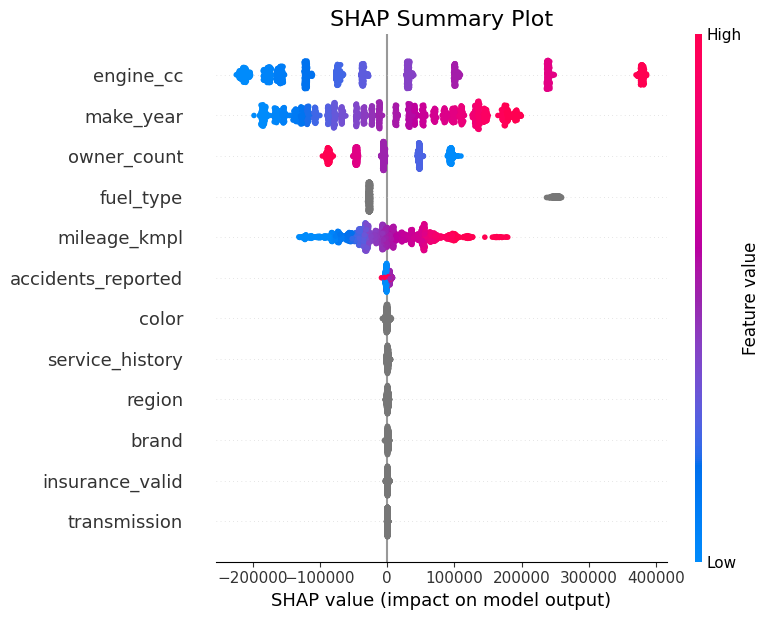

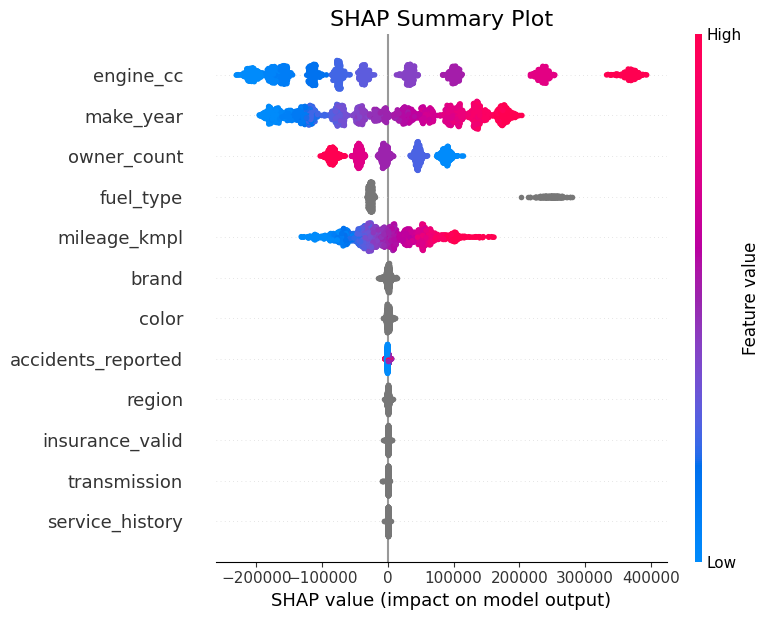

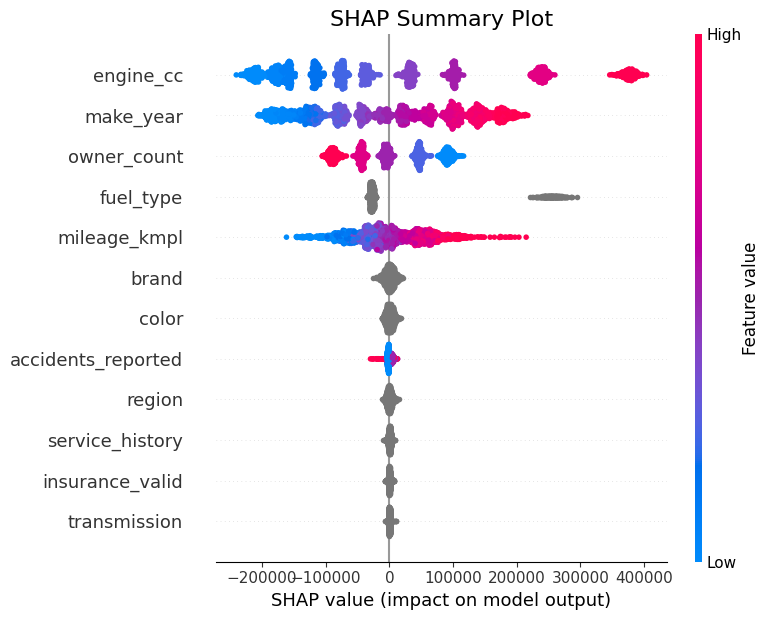

In [83]:
shap_plot(best_catb)
shap_plot(best_xgb)
shap_plot(best_lgb)

In [84]:
def dependence_plot(model, col_name):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)
    shap.dependence_plot(col_name, shap_values, X_val, interaction_index=None)

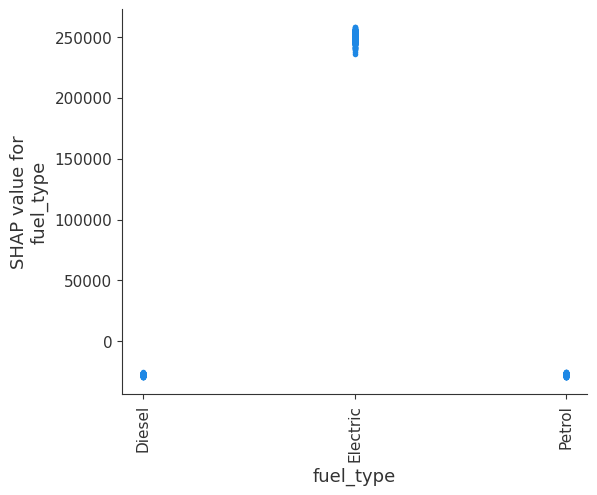

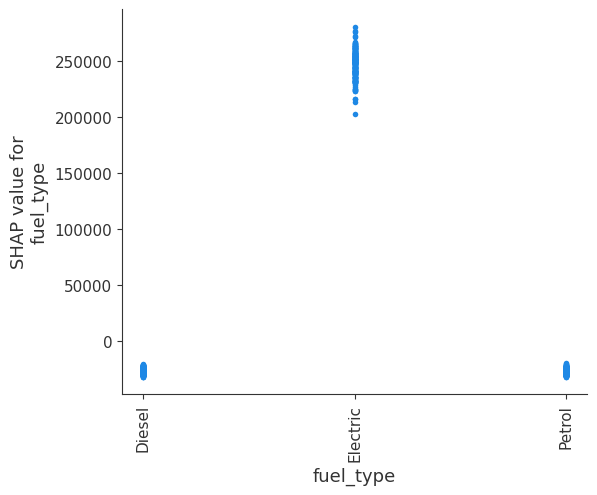

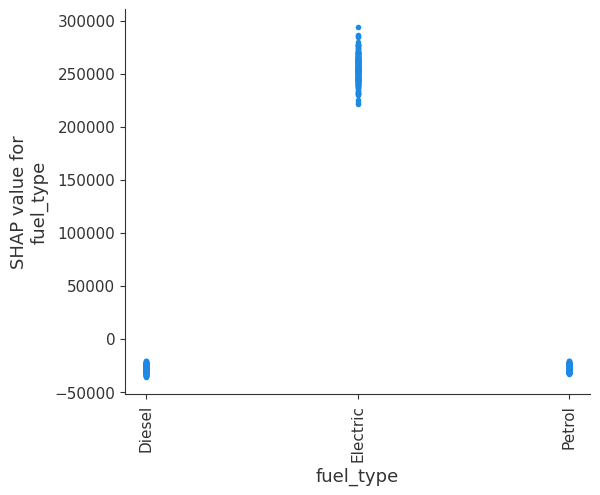

In [85]:
dependence_plot(best_catb, 'fuel_type')
dependence_plot(best_xgb, 'fuel_type')
dependence_plot(best_lgb, 'fuel_type')

Все 3 оптимизированные модели выделяют одинаковые Топ-5 признаков, вносящих наибольший вклад в цену автомобиля:
  - Объем двигателя (прямая зависимость) : вполне логично - чем мощнее двигатель, тем дороже автомобиль
  - Год выпуска автомобиля (прямая зависимость) : более новые автомобили стоят дороже
  - Количество владельцев (обратная зависимость) : чем меньше владельцев, тем юридически чище автомобиль и аккуратность эксплуатации
  - Тип топлива : в каждой из моделей отмечается, что элекрический тип двигателя увеличивает стоимость автомобиля
  - Километров на литр (прямая зависимость) : чем больше топливная эффективности автомобиля, тем он дороже

Как специфические признаки (например, color или insurance_valid)
Специфические признаки, такие как цвет автомобиля, наличие страховки или наличие сервисной книжки не оказывает существенного влияния на цену автомобиля

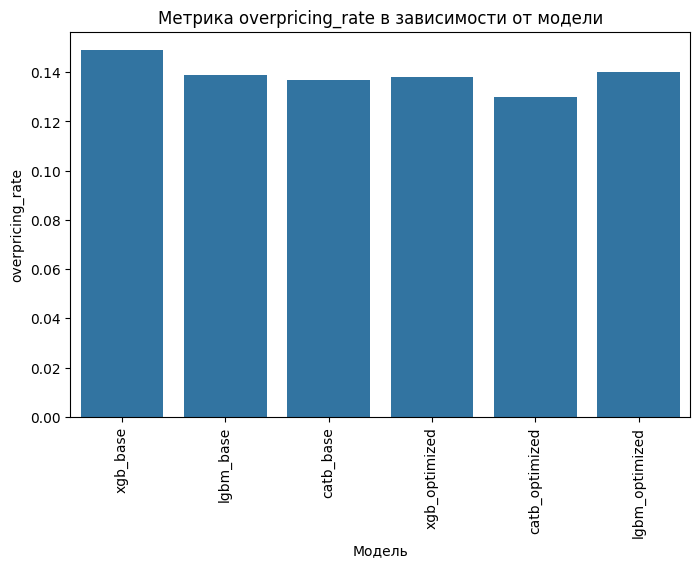

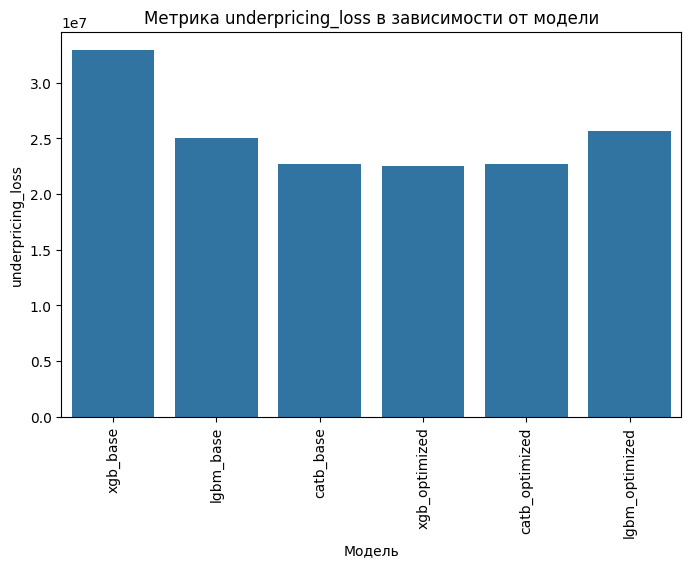

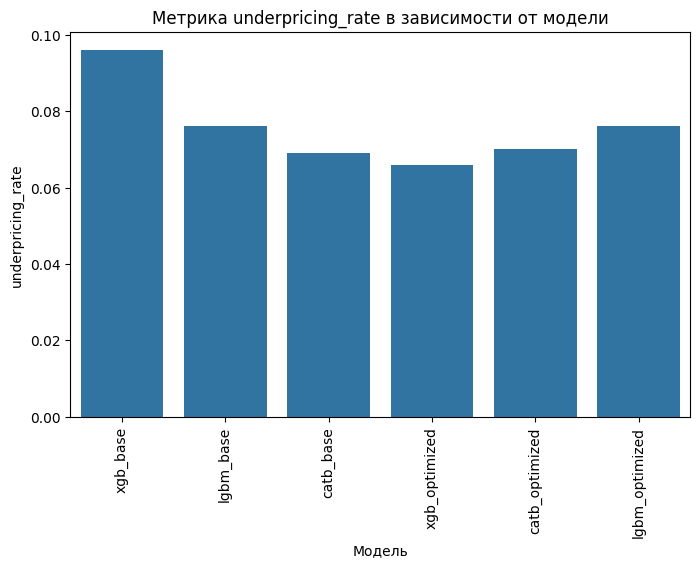

In [91]:
for i in res_table.columns[-3:]:
    plt.figure(figsize=(8, 5))
    sns.barplot(res_table, x='model', y=i)
    plt.xticks(rotation=90)
    plt.title(f'Метрика {i} в зависимости от модели')
    plt.xlabel('Модель')
    plt.show()

С точки зрения бизнес метрик наилучшими моделями являются xgboost и catboost модели

In [93]:
df_val_xgb = df_val.copy()
df_val_xgb['pred'] = y_pred_val_b_xgb

In [94]:
def categoty_metrics(y_pred, model_name):
    df_t = df_val.copy()
    df_t['pred'] = y_pred
    df_t['rate'] = (df_t['pred']-df_t['true']) / df_t['true']

    df_bellow = df_t[df_t['rate']< 0] 
    df_under = df_t[df_t['rate']> 0] 

    # Барплоты по марке авто
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_t, x='brand', y='rate')
    plt.xticks(rotation=90)
    plt.title(f'Метрика Переплат/Упущенной выгоды в зависимости от марки авто - Обший график (Модель {model_name})')
    plt.xlabel('Марка автомобиля')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_bellow, x='brand', y='rate')
    plt.xticks(rotation=90)
    plt.title(f'Метрика Упущенной выгоды в зависимости от марки автомобиля (Модель {model_name})')
    plt.xlabel('Марка автомобиля')
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_under, x='brand', y='rate')
    plt.xticks(rotation=90)
    plt.title(f'Метрика Переплат в зависимости от марки автомобиля (Модель {model_name})')
    plt.xlabel('Марка автомобиля')
    plt.show()

    print()

    # Барплоты по региону
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_t, x='region', y='rate')
    plt.xticks(rotation=90)
    plt.title(f'Метрика Переплат/Упущенной выгоды в зависимости от региона - Обший график (Модель {model_name})')
    plt.xlabel('Регион')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_bellow, x='region', y='rate')
    plt.xticks(rotation=90)
    plt.title(f'Метрика Упущенной выгоды в зависимости от региона (Модель {model_name})')
    plt.xlabel('Регион')
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_under, x='region', y='rate')
    plt.xticks(rotation=90)
    plt.title(f'Метрика Переплат в зависимости от региона (Модель {model_name})')
    plt.xlabel('Регион')
    plt.show()

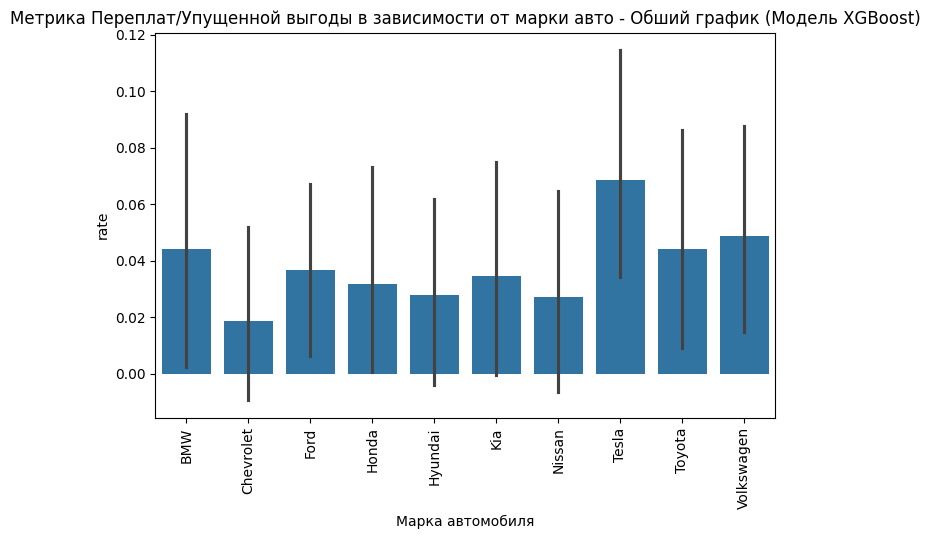

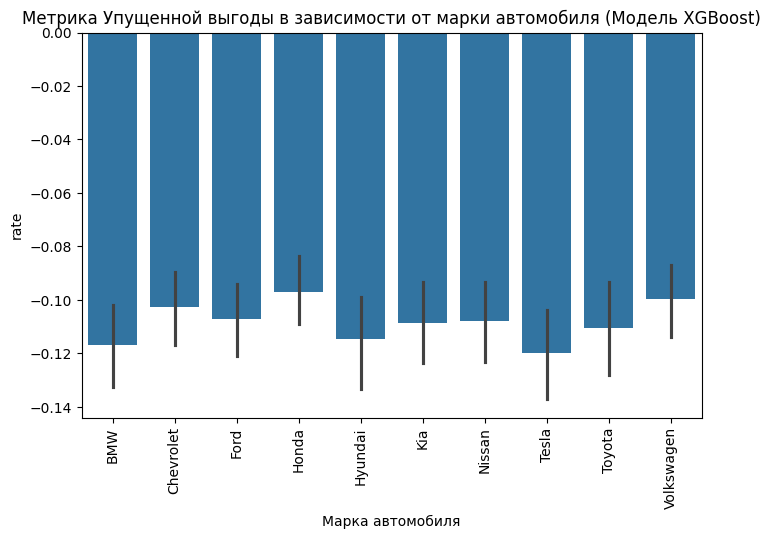

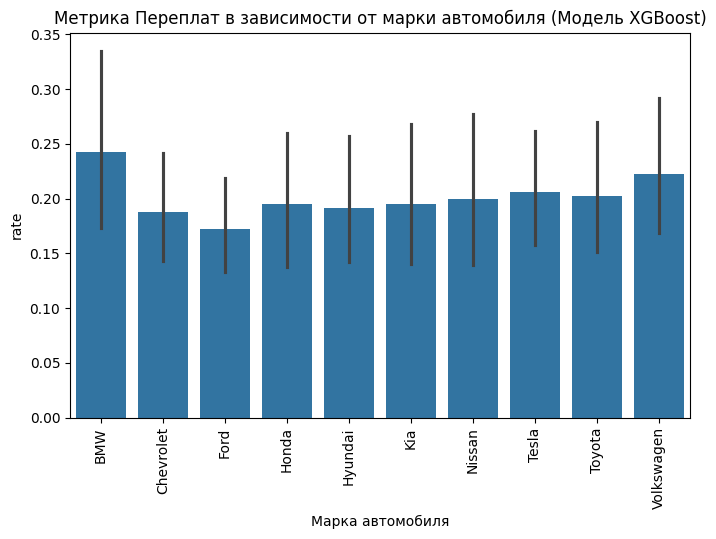

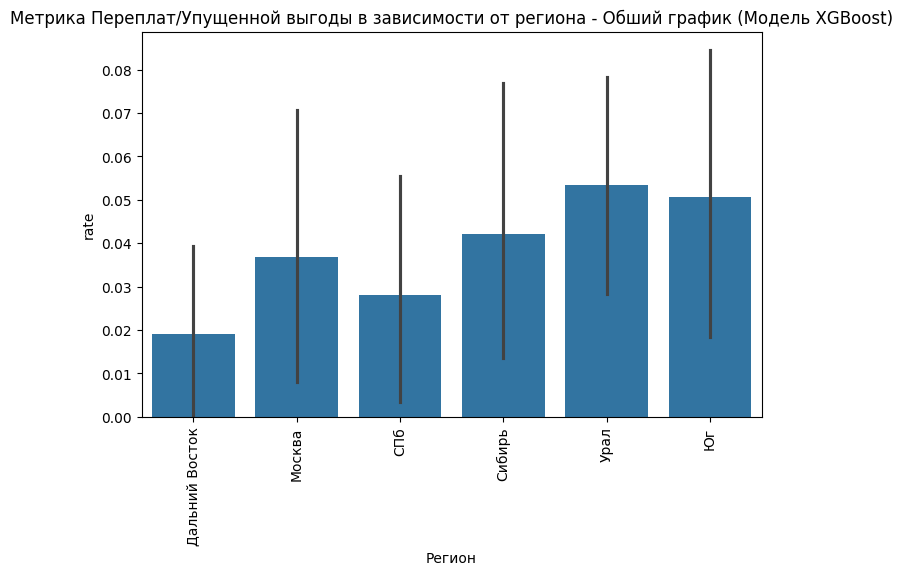

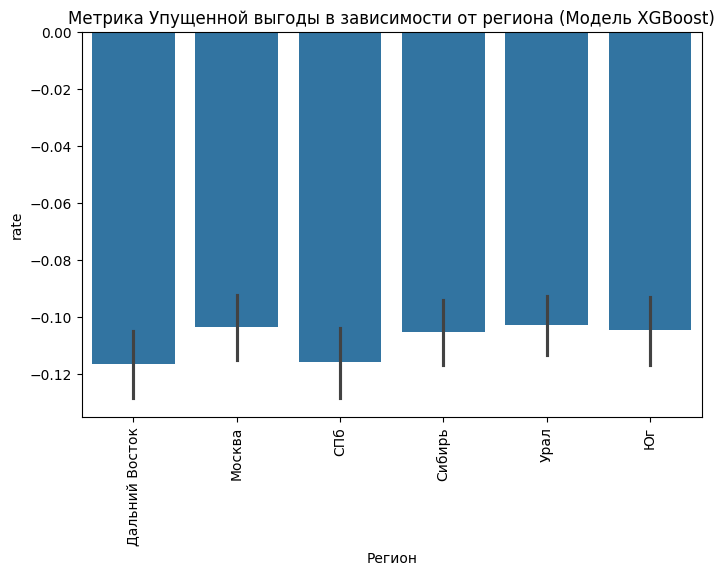

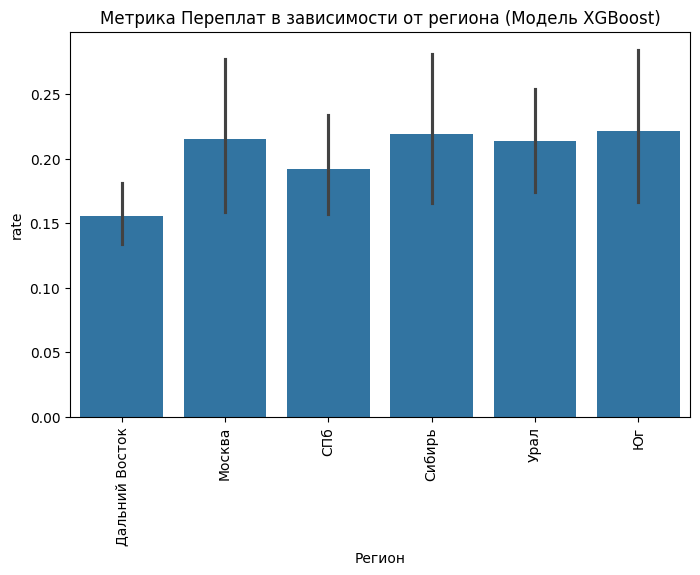


 ---------------------------------------------------------------------- 



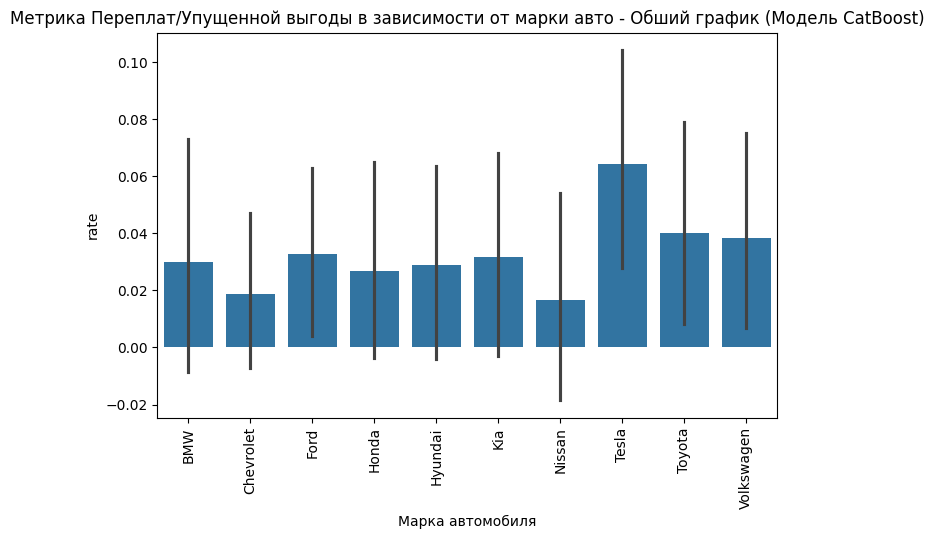

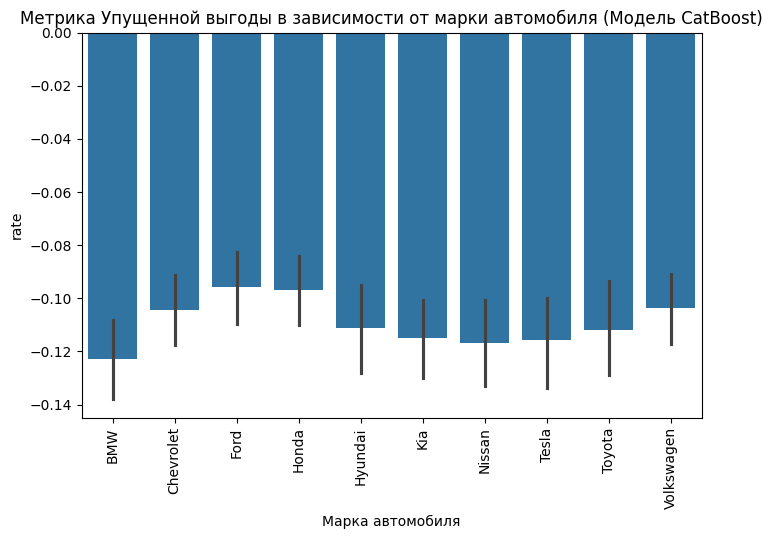

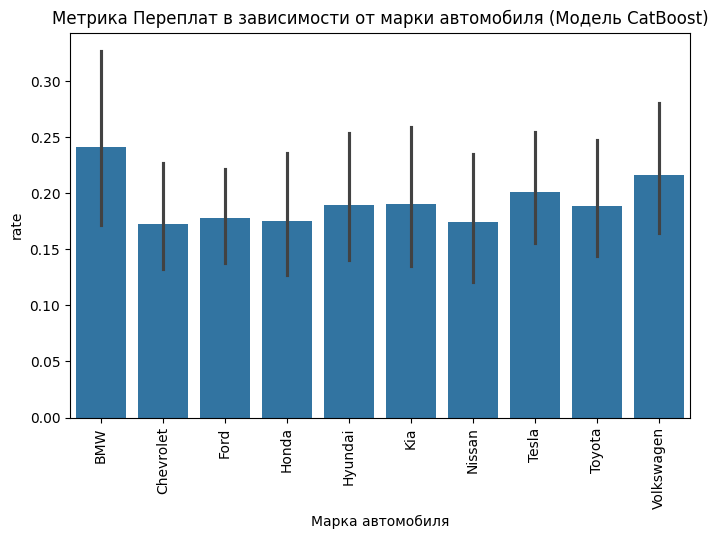

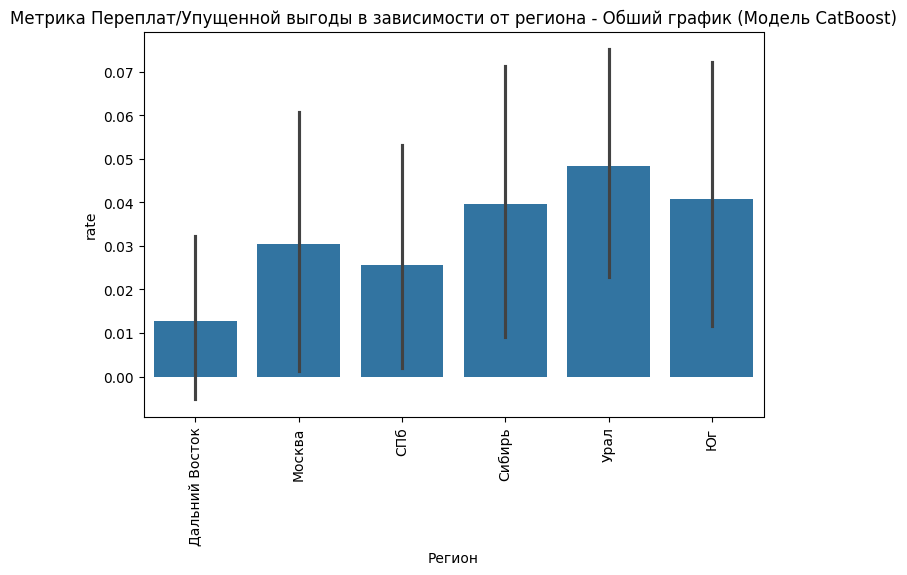

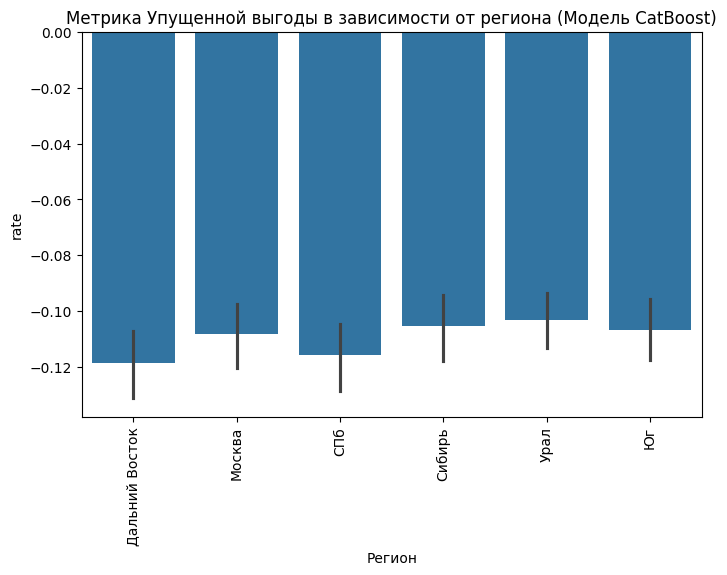

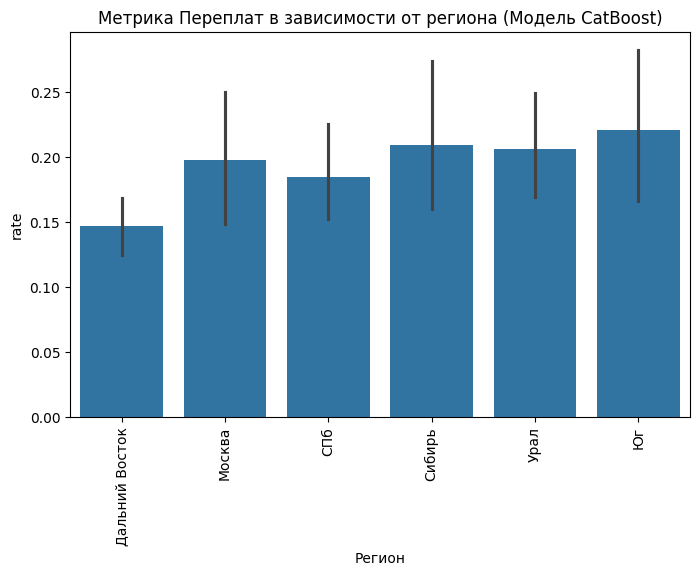


 ---------------------------------------------------------------------- 



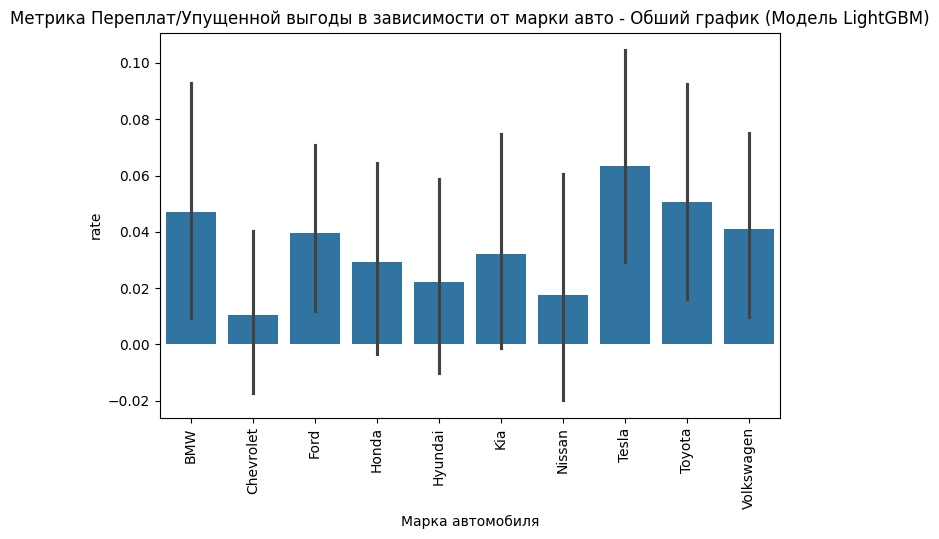

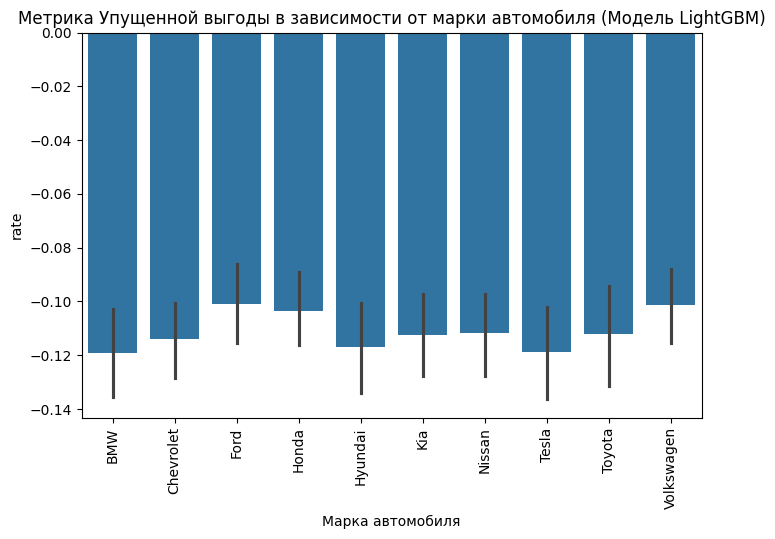

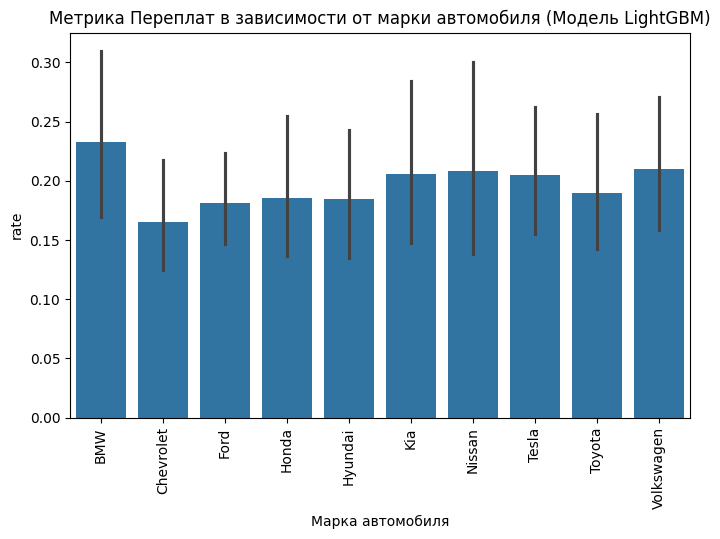

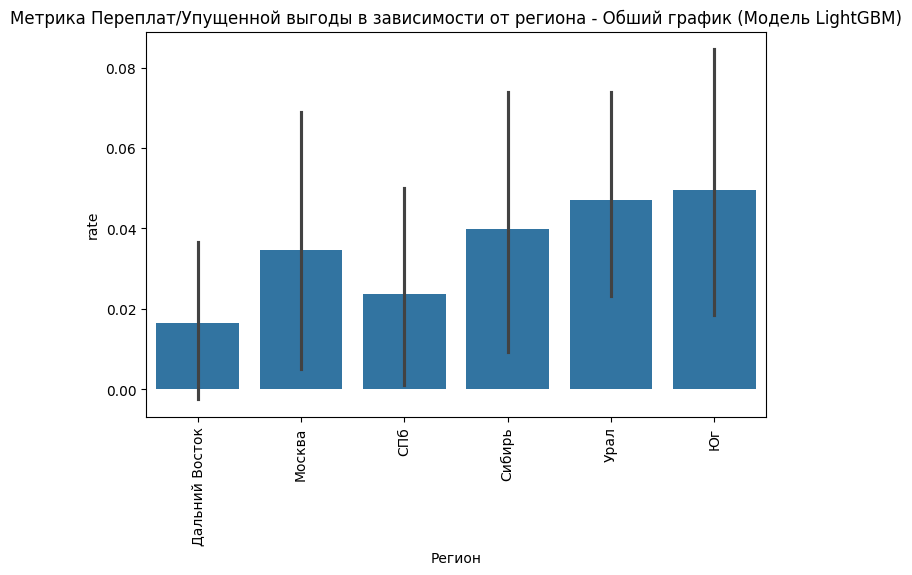

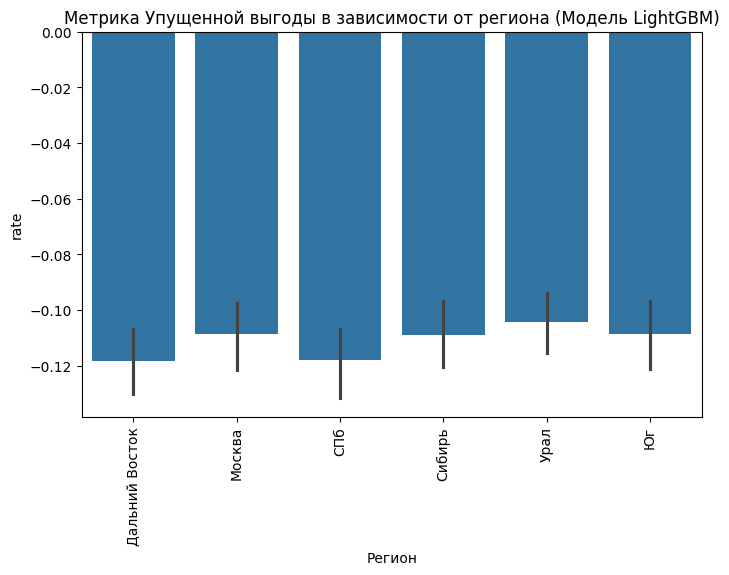

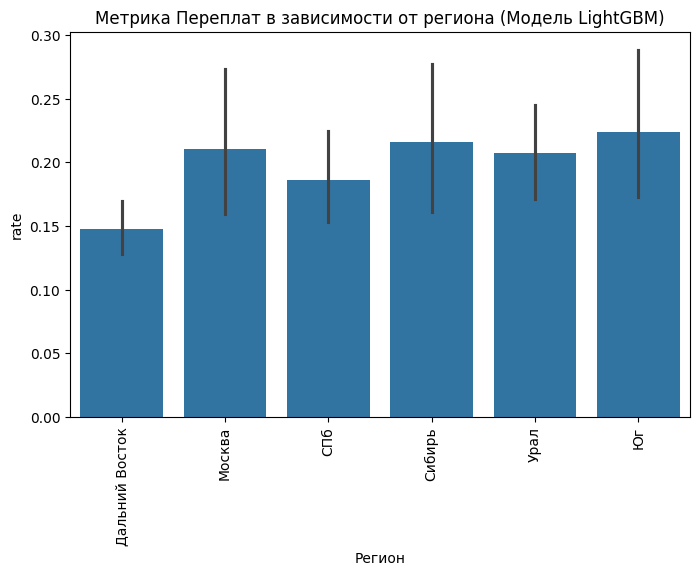

In [95]:
categoty_metrics(y_pred_val_b_xgb, 'XGBoost')
print('\n', '-' * 70, '\n')
categoty_metrics(y_pred_val_b_catb, 'CatBoost')
print('\n', '-' * 70, '\n')
categoty_metrics(y_pred_val_b_lgb, 'LightGBM')

Все рассматриваемые модели более склонны к завышению стоимости автомобилей.

Модель XGBoost:
  - Ни одна марка авто не достигает опасного порога Underpricing Rate
  - В среднем для марок Tesla, Volkswagen и BMW модель опасно завышает цену, для них требуется дополнительная ручная проверка
  - Ни один регион не достигает опасного порога Underpricing Rate
  - В среднем для регионов Юг, Сибирь и Урал модель опасно завышает цену, для них требуется дополнительная ручная проверка

Модель Catboost:
  - Ни одна марка авто не достигает опасного порога Underpricing Rate
  - В среднем для марок Tesla, Volkswagen и BMW модель опасно завышает цену, для них требуется дополнительная ручная проверка. Особенно стоит уделять внимание марке BMW
  - Ни один регион не достигает опасного порога Underpricing Rate
  - В среднем для регионов Юг, Сибирь и Урал модель опасно завышает цену, для них требуется дополнительная ручная проверка. Москва стоит на границе опасного порога

Модель LightGBM:
  - Ни одна марка авто не достигает опасного порога Underpricing Rate
  - В среднем для марок Tesla, Volkswagen, Nissan и BMW модель опасно завышает цену, для них требуется дополнительная ручная проверка
  - Ни один регион не достигает опасного порога Underpricing Rate
  - В среднем для регионов Москва, Юг, Сибирь и Урал модель опасно завышает цену, для них требуется дополнительная ручная проверка

<a id='8'></a>
# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

Лучшей моделью с точки зрения баланса между базовыми метриками и бизнес-метриками является модель Catboost с подбором гиперпараметров

In [100]:
y_pred_test = best_catb.predict(X_test)
print("Результаты CatBoost на тестовой выборке")
get_metrics(y_test, y_pred_test, 'CatBoost')

Результаты CatBoost на тестовой выборке


,model,mae,rmse,r2,overpricing_rate,underpricing_loss,underpricing_rate
0,CatBoost,75833.84,95166.55,0.874,0.13,21377067.8,0.064


In [101]:
print("Результаты CatBoost на валидационной выборке")
res_table[res_table['model']=='catb_optimized']

Результаты CatBoost на валидационной выборке


,model,mae,rmse,r2,overpricing_rate,underpricing_loss,underpricing_rate
0,catb_optimized,79278.45,98853.96,0.861,0.13,22723008.2,0.07


Метрики на тестовой выборке не ухудшились относительно валидационной, что свидетельствует об отсутствии переобучения и стабильности модели

<a id='9'></a>
# **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная для внедрения модель: Catboost

2. Точность оценки: в среднем модель ошибается на 75_834 руб. Коэффициент детерминации равен  0.874, что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне 13%. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до 21_377_069 руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионах Сибири, Юга и Урала и на марках Tesla, Volkswagen и BMW, особенно стоит уделить внимание BMW.

6. Лучшие гиперпараметры модели Catboost для интеграции в мобильное приложение:
  - 'learning_rate': 0.03912141628549695
  - 'depth': 3
  - 'iterations': 1411
  - 'l2_leaf_reg': 2.5347171131856236
---